<a href="https://colab.research.google.com/github/nathil/Matematica-Computacional/blob/main/Trabalhos/Atividade_2_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *Matemática Computacional* - ***Atividade 2.2***

*O vigente notebook tem como objetivo aplicar os conceitos de regressão linear, p-value e métricas. Além disso, há presente os conceitos de fatoração e pivoteamento parcial técnicas ultizadas no método de Gauss-Jacobi e Gauss-Seidel.*

Com isso, utilizaremos as seguintes bibliotecas:
* `numpy` para executar as operações matemáticas e criação de arrays.
* `matplotlib` para desenhar os gráficos que serão utilizados.
* `spicy` para calcular a regressão linear.
* `math` para calcular determinadas expressões matemáticas.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from scipy import stats
from scipy.stats import norm
from scipy.stats import t
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import pandas as pd


# *Funções*

In [3]:
def retorna_lista(caminho: str):
  '''
  A função lê o arquivo e tranforma em uma lista com valores float
  '''

  dados = " "
  lista_dados = []

  with open(caminho, "r", encoding="utf-8") as arquivo:
      dados = arquivo.readlines()

      for dado in dados[1:]:
        lista_dados.append(dado)

  return [float(i) for i in lista_dados]

In [4]:
def retorna_lista_dataset(caminho: str):
  '''
  A função lê o arquivo e tranforma em uma lista com valores float
  '''

  dados = " "
  lista_dados = []
  coluna_desejada = 1

  with open(caminho, "r", encoding="utf-8") as arquivo:
      dados = arquivo.readlines()

      for linha in dados[1:]:
        coluna = linha.split(",")
        if len(coluna) > coluna_desejada:
          lista_dados.append(coluna[coluna_desejada].strip())


  return [float(i) for i in lista_dados]

# *Letra A*

Valor-p: 0.00
Covariância: 0.43


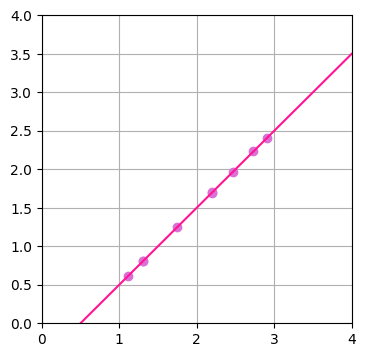

In [89]:
np.random.seed(42)
x = ((np.random.rand(9) * 2) + 1 )
y = x - 0.5

x_media = sum(x) / len(x)
y_media = sum(y) / len(y)


covariance = sum([(x - x_media)*(y - y_media) for x, y in zip(x, y)])/(len(x) - 1) #calcula covariância usando list comprehension

slope, intercept, _, p_value, _ = stats.linregress(x, y)  #recebe slope, intercept e p_value

result = stats.linregress(x, y)
line_x = np.linspace(0, 4, 2)  #pegamos o ponto para calcular o y para esse x
line_y = line_x * result.slope + result.intercept
fig, ax = plt.subplots(1,1, figsize=(4, 4)) #definindo o tamanho do gráfico

ax.grid(True)

ax.set_xlim(0, 4) #definindo o limite de x
ax.set_ylim(0, 4) #definindo o limite de y
ax.plot(x, y, 'o', color='Orchid') #plotando os ponto no gráfico
ax.plot(line_x, line_y, color='DeepPink') #plotando a linha no gráfico

print(f'Valor-p: {result.pvalue:.2f}')
print(f'Covariância: {covariance:.2f}')
plt.show()


Podemos observar a partir do valor do p-value, que como ele está abaixo da margem de $0,05\%$ isso é um indicativo de que os coeficientes do modelo são estatisticamente significativos, ou seja, as variáveis independentes possuem um grande impacto na variável dependente, demonstrando que o resultado não é fruto do acaso.
<br>
Com relação a covariância, podemos observar que como o valor é positivo então $X$ e $Y$ se movem juntos. Um valor de $0,43$ da covariância não indica uma relação fraca ou forte, ou seja, os dados não estão nem em uma linha reta perfeita, nem dispersos pelo gráfico -- o que podemos observar, visto que por mais que os pontos sigam a reta da regressão ainda não estão perfeitamente alinhados.

Valor-p: 0.73
Covariância: 0.19


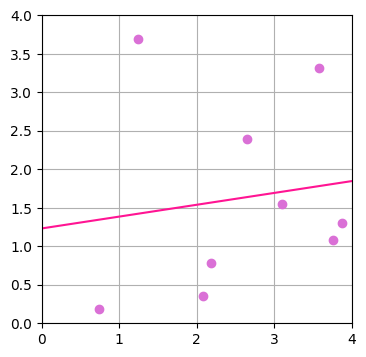

In [88]:
x = np.random.uniform(0, 4, 9)
y = np.random.uniform(0, 4, 9)

x_media = sum(x) / len(x)
y_media = sum(y) / len(x)

covariance = sum([(x - x_media)*(y - y_media) for x, y in zip(x, y)])/(len(x) - 1) #calcula a covariância com list comprehension

slope, intercept, _, p_value, _ = stats.linregress(x, y) #recebe slope, intercept e p_value

result = stats.linregress(x, y)
line_x = np.linspace(0, 4, 2)  #pegamos o ponto para calcular o y para esse x
line_y = line_x * result.slope + result.intercept
fig, ax = plt.subplots(1,1, figsize=(4, 4)) #definindo o tamanho do gráfico

ax.grid(True)

ax.set_xlim(0, 4) #definindo o limite de x
ax.set_ylim(0, 4) #definindo o limite de y
ax.plot(x, y, 'o', color='Orchid') #plotando os pontos no gráfico
ax.plot(line_x, line_y, color='DeepPink') #plotando a linha no gráfico

print(f'Valor-p: {result.pvalue:.2f}')
print(f'Covariância: {covariance:.2f}')
plt.show()

A partir do gráfico podemos analisar que o valor do p-value é maior do que a margem de $0,05\%$, isso significa que o coeficiente da variável preditora não é estatisticamente relevante. Ou seja, essa váriavel não tem um efeito linear considerável na variável dependente.

Com relação a covariância, como o seu valor é positivo podemos inferir que conforme $X$ aumenta $Y$ também aumenta. Porém o valor da covariância é próximo de 0, o que indica que os dados apresentados não seguem uma reta perfeita e estão bastante dispersos em torno da reta da regressãa, fato que pode ser confirmado pelo gráfico.

# *Letra B*

49.53
21.55
[-5.98, 105.03]
[7.30, 91.76]
[14.09, 84.97]


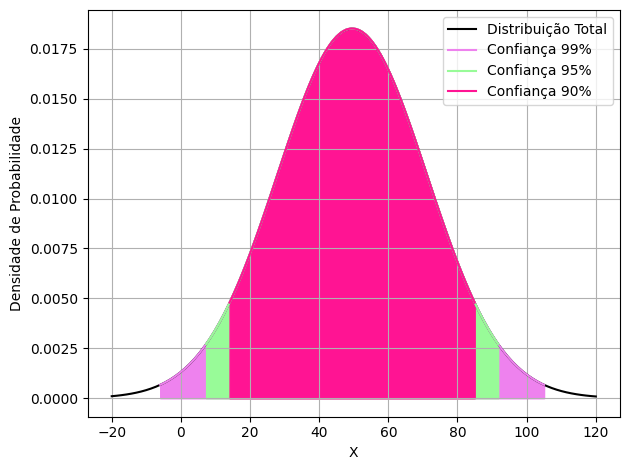

In [78]:
lista_valores = retorna_lista("/content/drive/MyDrive/Colab Notebooks/atividade 2.2/valores.csv")

media = sum(lista_valores)/len(lista_valores)
desvio_padrao = math.sqrt(sum([(i - media)**2 for i in lista_valores])/len(lista_valores)) #calcula o desvio padrao com list comprehension

valor1, valor2 = norm.interval(0.99, media, desvio_padrao)
valor3, valor4 = norm.interval(0.95, media, desvio_padrao)
valor5, valor6 = norm.interval(0.90, media, desvio_padrao)

print(f'{media:.2f}')
print(f'{desvio_padrao:.2f}')

print(f'[{valor1:.2f}, {valor2:.2f}]')
print(f'[{valor3:.2f}, {valor4:.2f}]')
print(f'[{valor5:.2f}, {valor6:.2f}]')


x1 = np.linspace(valor1, valor2, 100) # Pontos para calcular a PDF
x2 = np.linspace(valor3, valor4, 100) # Pontos para calcular a PDF
x3 = np.linspace(valor5, valor6, 100) # Pontos para calcular a PDF
x4 = np.linspace(-20, 120, 100) # Calculando a maior curva


p1 = norm.pdf(x1, loc=media, scale=desvio_padrao)
p2 = norm.pdf(x2, loc=media, scale=desvio_padrao)
p3 = norm.pdf(x3, loc=media, scale=desvio_padrao)
p4 = norm.pdf(x4, loc=media, scale=desvio_padrao)


plt.xlabel('X')
plt.ylabel('Densidade de Probabilidade')

plt.plot(x4, p4, color='black', label='Distribuição Total')
plt.plot(x1, p1, 'Violet', label='Confiança 99%')
plt.plot(x2, p2, 'PaleGreen', label='Confiança 95%')
plt.plot(x3, p3, 'DeepPink', label='Confiança 90%')

plt.fill_between(x1, p1, color='Violet', alpha=1)
plt.fill_between(x2, p2, color='PaleGreen', alpha=1)
plt.fill_between(x3, p3, color='DeepPink', alpha=1)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


O intervalo de confiança de $99\%$ indica uma baixa precisão, mas uma maior certeza de que o verdadeiro valor populacional está dentro da faixa, apesar de ser menos preciso ele é um intervalo mais seguro, ou seja, neste caso temos $99\%$ de certeza de que a média estão entre -5.98 e 105.03. O intervalo de $95\%$ é mais preciso do que o de $99\%$ e tem uma margem de erro menor do que o intervalo de $99\%$, desse modo, há $95\%$ de certeza que a média está entre 7.30 e 91.76. Por fim, o intervalo de confiança de $90\%$ é o mais preciso dentre os três já que é o menor intervalo de todos, ou seja, a precisão é a maior e tem a menor média de erros, com isso, podemos concluir que há $90\%$ de certeza de que a média está entre 14.09 e 84.97.

# *Letra C*

Para realizar o experimento a hipótese nula escolhida foi:
$H_0 = $ A média peso entre pessoas altas e baixas é a mesma.
<br>
A Hipótese alternativa escolhida foi:
$H_a = $ A média de peso entre pessoas altas e baixas é diferente

In [8]:
lista_altos = retorna_lista_dataset("/content/drive/MyDrive/Colab Notebooks/atividade 2.2/tall.csv")
lista_baixos = retorna_lista_dataset("/content/drive/MyDrive/Colab Notebooks/atividade 2.2/short.csv")

media_altos = sum(lista_altos)/len(lista_altos)
media_baixos = sum(lista_baixos)/len(lista_baixos)

# Realizando o teste t independente
t_stat, p_value = stats.ttest_ind(lista_altos, lista_baixos)

print(f'media peso para altos: {media_altos:.2f}')
print(f'media peso para baixos: {media_baixos:.2f}')

print(f'Test t: {t_stat:.2f}')
print(f'P-Value: {p_value:.2f}')


media peso para altos: 62.81
media peso para baixos: 52.34
Test t: 62.12
P-Value: 0.00


Como o valor do p-value está abaixo de 0.05 (quando podemos rejeitar a hipótese nula), então podemos concluir após a análise do p-value que podemos recursar a hipótese nula, ou seja, a media de peso de pessoas altas e baixas é realmente diferente. Como o valor do Test-t é grande, podemos inferir que há uma evidência maior contra a hipotése nula, ou seja, há uma diferença estatística significativa entre as médias.

# *Letra D*

O link para os slides da questão: https://www.canva.com/design/DAG_q63DJZs/DNksUoJB7SVG9NkwFzbVQA/edit?utm_content=DAG_q63DJZs&utm_campaign=designshare&utm_medium=link2&utm_source=sharebutton

# *Letra E*

2.01
79.20
10.70
[69.58, 88.82]


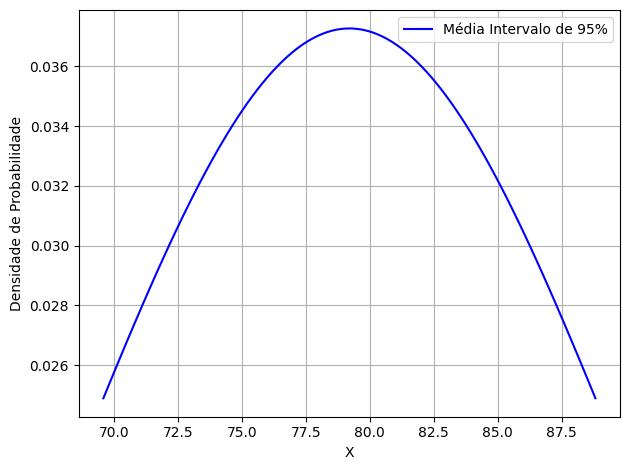

In [9]:
lista = [100, 74, 74, 78, 70]

media = sum(lista)/len(lista)
desvio_padrao = math.sqrt(sum([(i - media)**2 for i in lista])/len(lista)) #calcula a covariância com list comprehension

# parâmetros
nivel_confianca = 0.975
grau_liberdade = 49

# calculando o t-critical
t_critical = t.ppf(nivel_confianca, grau_liberdade)

# calculando o intervalo de confiança
valor1 = media + t_critical*(desvio_padrao/np.sqrt(len(lista))) # intervalo da média amostral
valor2 = media - t_critical*(desvio_padrao/np.sqrt(len(lista))) # intervalo da média amostral

print(f'{t_critical:.2f}')
print(f'{media:.2f}')
print(f'{desvio_padrao:.2f}')
print(f'[{valor2:.2f}, {valor1:.2f}]')

x1 = np.linspace(valor2, valor1, 100)

p1 = norm.pdf(x1, loc=media, scale=desvio_padrao)

plt.xlabel('X')
plt.ylabel('Densidade de Probabilidade')

plt.plot(x1, p1, 'b-', label='Média Intervalo de 95%')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



1.96
0.2
0.55
-0.15


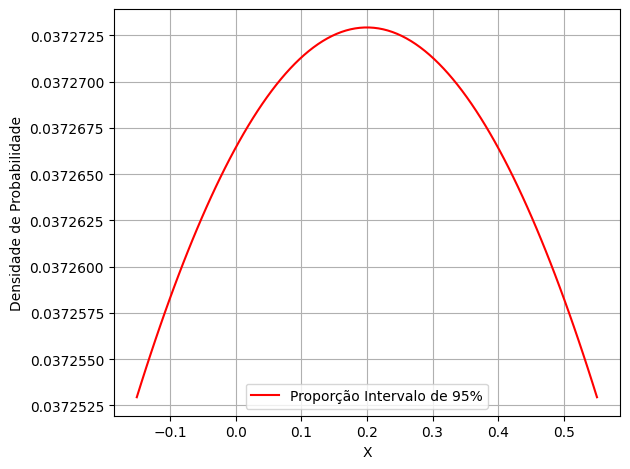

In [10]:
# Código para gráfico da proporção

p = 1/len(lista) # p representa o número de mulheres que têm bpms a partir de 100, dividido pela quantidade de pessoas

# calculando z-critical
z_critical = norm.ppf(nivel_confianca)

# calculando p
valor3 = p + z_critical*(np.sqrt((p*(1-p)/len(lista)))) # calculando o intervalo de confiança da proporção amostral
valor4 = p - z_critical*(np.sqrt((p*(1-p)/len(lista)))) # calculando o intervalo de confiança da proporção amostral

x2 = np.linspace(valor4, valor3, 100) # intervalo para x usando os valores 3 e 4

p2 = norm.pdf(x2, loc=p, scale=desvio_padrao) # definindo a função, loc=p para mostrar em relação a proporção e não a média

# Mostrando Valores
print(f'{z_critical:.2f}')
print(f'{p}')
print(f'{valor3:.2f}')
print(f'{valor4:.2f}')

# Desenhando o Gráfico
plt.xlabel('X')
plt.ylabel('Densidade de Probabilidade')

plt.plot(x2, p2, 'r-', label='Proporção Intervalo de 95%')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# *Letra F*

### *Reprodução do Gráfico*

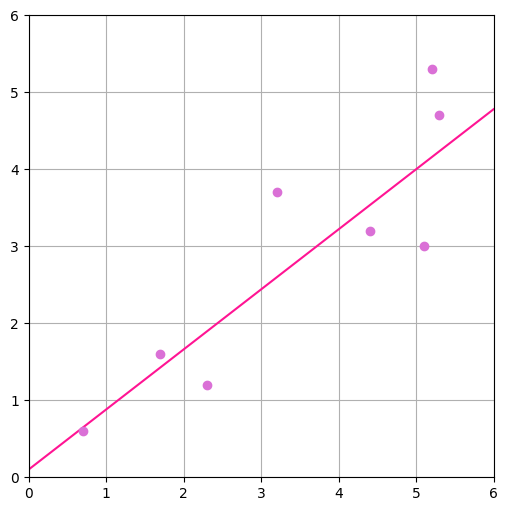

In [71]:
x_f = np.array([0.7, 1.7, 2.3, 3.2, 4.4, 5.1, 5.2, 5.3])
y_f = np.array([0.6, 1.6, 1.2, 3.7, 3.2, 3.0, 5.3, 4.7])


line_x = np.linspace(0, 6, 2)  #pegamos o ponto para calcular o y para esse x
line_y = line_x * 0.78 + 0.1

fig, ax = plt.subplots(1,1, figsize=(6, 6)) #definindo o tamanho do gráfico

ax.plot(line_x, line_y, color='DeepPink') #plotando a linha no gráfico

ax.grid(True)

ax.set_xlim(0, 6) #definindo o limite de x
ax.set_ylim(0, 6) #definindo o limite de y
ax.plot(x_f, y_f, 'o', color='Orchid') #plotando os ponto no gráfico
plt.show()

### *Regressão Linear*

Coeficiente (inclinação): [0.82914005]
Intercept: 0.020874088313451722


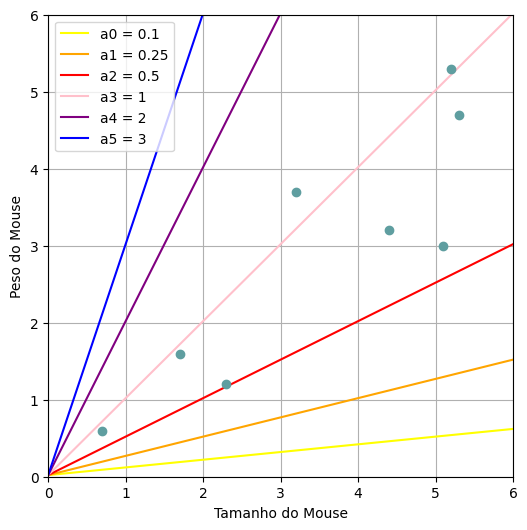

In [73]:

model = LinearRegression()

reshape_x = x_f.reshape(-1, 1)
model.fit(reshape_x, y_f)

print(f"Coeficiente (inclinação): {model.coef_}")
print(f"Intercept: {model.intercept_}")

line_x = np.linspace(0, 6, 2)
line_y = lambda x: line_x*x + model.intercept_ # função para calcular a funcao com a's diferentes

fig, ax = plt.subplots(1,1, figsize=(6, 6)) #definindo o tamanho do gráfico

ax.plot(line_x, line_y(0.1), color='yellow', label='a0 = 0.1') #plotando a linha no gráfico
ax.plot(line_x, line_y(0.25), color='orange', label='a1 = 0.25') #plotando a linha no gráfico
ax.plot(line_x, line_y(0.5), color='red', label='a2 = 0.5') #plotando a linha no gráfico
ax.plot(line_x, line_y(1), color='pink', label='a3 = 1') #plotando a linha no gráfico
ax.plot(line_x, line_y(2), color='purple', label='a4 = 2') #plotando a linha no gráfico
ax.plot(line_x, line_y(3), color='blue', label='a5 = 3') #plotando a linha no gráfico

ax.grid(True)

plt.xlabel('Tamanho do Mouse')
plt.ylabel('Peso do Mouse')

ax.set_xlim(0, 6) #definindo o limite de x
ax.set_ylim(0, 6) #definindo o limite de y
ax.plot(x_f, y_f, 'o', color='CadetBlue') #plotando os ponto no gráfico

plt.legend()
plt.show()

    Slope         SSR         R²  R² Ajustado  F-Statistic  Prob F-Statistic
a0   0.20   51.674108  -1.635258    -2.074467    -3.723183          1.000000
a1   0.25   44.460072  -1.267359    -1.645252    -3.353749          1.000000
a2   0.50   17.345640   0.115413    -0.032018     0.782828          0.410329
a3   1.00    7.895527   0.597347     0.530238     8.901158          0.024526
a4   2.00  168.110302  -7.573229    -9.002100    -5.300147          1.000000
a5   3.00  567.145076 -27.923061   -32.743571    -5.792553          1.000000
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     20.68
Date:                Tue, 03 Feb 2026   Prob (F-statistic):            0.00390
Time:                        23:02:52   Log-Likelihood:           

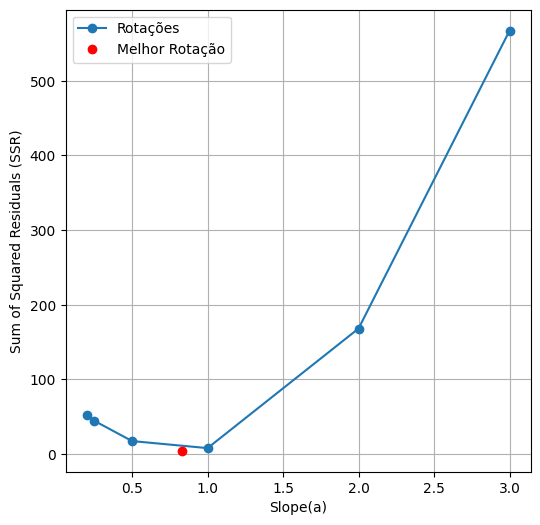

In [74]:
lista_slope = [0.2, 0.25, 0.5, 1, 2, 3]
lista_r2 = []
lista_ssr = []
lista_r2_adj = []
lista_f_statistic = []
lista_prob_f_stats = []

p = reshape_x.shape[1]
n = reshape_x.shape[0]

for slope in lista_slope:
  model_r2 = LinearRegression()
  model_r2.coef_ = np.array([slope])  # recebe os valores da lista
  model_r2.intercept_ = model.intercept_
  model_r2_score = model_r2.score(reshape_x, y_f)

  y_pred = model_r2.predict(reshape_x)

  lista_ssr.append(float(np.sum((y_f - y_pred)**2)))
  lista_r2.append(model_r2_score)
  lista_r2_adj.append(1 - (1 - model_r2_score) * ((n - 1) / (n - p - 1))) # calculando o r2 ajustado
  lista_f_statistic.append((model_r2_score/(1 - model_r2_score)) * (n - 2))
  lista_prob_f_stats.append(1 - stats.f.cdf(lista_f_statistic[-1], 1, n-2))

#tabela
data = [
    *zip(lista_slope, lista_ssr, lista_r2, lista_r2_adj, lista_f_statistic, lista_prob_f_stats)
]

df = pd.DataFrame(data, columns=['Slope', 'SSR', 'R²', 'R² Ajustado', 'F-Statistic', 'Prob F-Statistic'], index=['a0', 'a1', 'a2', 'a3', 'a4', 'a5'])

print(df)


#Estimativa da Linha
linearRegression = sm.OLS(y_f, sm.add_constant(x_f)).fit()
print(linearRegression.summary())

fig, ax = plt.subplots(1,1, figsize=(6, 6)) #definindo o tamanho do gráfico

plt.xlabel('Slope(a)')
plt.ylabel('Sum of Squared Residuals (SSR)')

ax.grid(True)

ax.plot(lista_slope, lista_ssr, 'o-', label='Rotações') # plotando os pontos dos diferentes a's do gráfico anterior

y_pred = model.predict(reshape_x) # predict do modelo

ax.plot(model.coef_[0], np.sum((y_f - y_pred)**2), 'o', color='red', label='Melhor Rotação') # plotando o melhor ponto/slope

plt.legend()
plt.show()


### R-Squared

O valor do R-Squared da melhor rotação é $0.775$, que ocorre quando o slope da melhor rotação é  $0.8291$. Assim, como o R-Squared representa o coeficiente de determinação, que vai indicar o quão bem as variáveis independentes explicam a variabilidade da variável dependente. Sendo assim, como o valor do R-Squared é acima de $0,7$ podemos concluir que há um forte indício de que o modelo de regressão linear tem um bom ajuste de dados. Com isso, podemos comparar com os outros valores do R-Squared obtidos, em que todos são menores próximos a zero ou muito distantes (valores negativos) de 0, por isso, a melhor rotação é classificada como a melhor devido ao seu bom ajuste. Os valores negativos de R-Squared indicam também que esses modelos de regressão linear é pior na previsão dos dados do que apenas calcular a média das variáveis dependentes.

### R-Squared Ajustado

O valor do R-Squared Ajustado da melhor rotação em relação ao R-Squared é um pouco menor, pois, o R-Squared Ajustado penaliza a inclusão de variáveis independentes que não melhoram significativamente o modelo. Enquanto o R-Squared aumenta quando novas variáveis são adicionadas.
<br>
Com isso, para os outros valores da rotação todos também foram menores que o R-Squared original, ou seja, alguns que eram positivos agora estão, também negativos, o que indica que esses modelos de regressão linear tem um desempenho pior do que o cálculo da média da variável dependente.

### F-Statistic

O F-statistic é uma medida que avalia a significância global de modelos de regressão ou diferenças entre médias. Neste caso, como o F-Statistic da melhor rotação tem valor $20.68$, que é considerado um valor alto, isso indica que há um significância estatística e possui pode preditivo,assim, podemos rejeitar a hipotése nula de que os valores dos coeficientes do modelo são nulos.
<br>
Os valores dos F-Statistics das outras rotações, possuem ou valor 0 ou menores que 0, o que indica que a variância entre os grupos é semelhante a variância dentro dos grupos, o que sugere que a hipotése nula é verdadeira, o que significa que há pouca ou nenhuma diferença entre os modelos comparados. Apenas um desses valores é bom, que é o do a3 que possue um valor de $8,03$ o que indica que o modelo de a3 é bom e possui boa capacidade preditiva.

### Prob(F-Statistic)

O Prob F-Statistic é uma medida que indica a significância global de um modelo de regressão, que avalia se os resultados obtidos ocorrem por fatores aleatórios a partir da margem de 0,05 como resultado de Prob F-Statistic. Deste modo, como o valor da melhor rotação é $0,03$, ou seja, menor do que $0,05$ podemos afirmar que o modelo é estatisticamente significativo e os valores obtidos não foram ao acaso e a hipotése nula pode ser rejeitada, assim concluimos que as variáveis independentes (X) ajudam a prever a variável dependente (Y).
<br>
A maior parte das outras rotações feitas possuem Prob F-Static maiores do que $0,05$, o que significa que os modelos de regressão não são estatisticamente significativos, ou seja, não há evidências suficientes para rejeitar a hipotése nula, o que pode indicar que as variáveis independentes não ajudam a significativamente a prever a variável dependente. Deste modo, apenas um valor foi abaixo da margem de $0,05$, que é o de a3, que teve um Prob F-Statistic de $0,02$, o que demonstra que o modelo é estatisticamente significativo e rejeita a hipotése nula de que a variável independente têm coeficientes 0. Assim, a variável independente (X) ajuda a prever a variável dependente (Y).

# *Letra G*

## *Fatoração LU com Pivoteamento Parcial*

A fatoração LU com pivoteamento parcial $PA = LU$, esse método decompõe uma matriz em três matrizes: $P$(permutação), $L$(triangular inferior) e $U$(triangular superior).
<br>
O seu funcionamento consiste em, encontrar um pivô na coluna j procurando pelo maior elemento em módulo abaixo da diagonal. Se o maior elemento estiver em uma linha inferior trocamos a linha atual pela linha desse elemento. Após isso, partimos para a eliminação, em que calculamos os multiplicadores
$$
m_{i,j} = \frac{a_{i,j}}{a_{j,j}}
$$

Assim, realizamos as operações nas linhas para zerar os elementos abaixo do pivô, armazenado-os na matriz L. Esse processo é repetido para as colunas seguintes até obtermos a forma superior $U$.

In [68]:
def calculo_fatores(a):
  n = len(a)
  p = [0 for _ in range(n)]# inicializando o vetor com tamanho n

  for i in range(n):
    p[i] = i # preenchendo com o valor de i

  for k in range(n-1):
    pv = abs(a[k][k])
    r = k

    for i in range(k+1, n):

      if abs(a[i][k]) > pv:
        pv = abs(a[i][k])
        r = i

    if pv == 0:
      return print('A matriz é singular')

    if r != k:
      aux = p[k]
      p[k] = p[r]
      p[r] = aux

      for j in range(n):
        aux = a[k][j]
        a[k][j] = a[r][j]
        a[r][j] = aux

    for i in range(k+1, n):
      m = a[i][k]/a[k][k]
      a[i][k] = m

      for j in range(k+1, n):
        a[i][j] = a[i][j] - m*a[k][j]

  return p, a




In [69]:

def resolucao_sistemas(p, a, b):
  n = len(a)
  c = [0 for _ in range(n)]
  y = [0 for _ in range(n)]
  x = [0 for _ in range(n)]

  for i in range(n):
    r = p[i]
    c[i] = b[r]

  for i in range(n):
    soma = 0
    for j in range(i):
      soma = soma + a[i][j]* y[j]
    y[i] = c[i] - soma

  for i in range(n-1, -1, -1):
    soma = 0
    for j in range(i+1, n):
      soma = soma + a[i][j]* x[j]
    x[i] = (y[i] - soma)/a[i][i]

  return y, x


### *Exemplo 7*

A aplicação da fatoração LU com estratégia de pivoteamento parcial no exemplo 7:

In [70]:
p, a = calculo_fatores([[3, -4, 1], [1, 2, 2], [4, 0, -3]]) # calculando
L, U = resolucao_sistemas(p, a, [9, 3, -2])
print('Valor de L:', L)
print('Valor de U:', U)

Valor de L: [-2, 10.5, 8.75]
Valor de U: [1.0, -1.0, 2.0]


# *Letra H*

O método iterativo de Gauss-Jacobi é utilizado para resolução de sistemas lineares $Ax = b$, do qual partimos de uma aproximação inicial $x^{(0)}$ para encontrar uma solução após múltiplas iterações, isolando cada variável da diagonal garatindo que não haja zeros na diagonal principal. Assim, para calcular a convergência também utilizamos o critério das linhas (ou matriz estritamente diagonal dominante), do qual o seu cálculo é feito a partir da fórmula:
$$
(|a_{i,i}|) > \sum_{j \neq i} |a_{i,j}|
$$

No qual, o processo é iterrompido quando a diferença entre as aproximações sucessivas é menor que a tolerância ϵ definida inicialmente:
$$
||x^{(k+1)} - x^{(k)}|| < ϵ
$$

Desse modo, as iterações feitas pelo método são dadas por:
$$
x_{i}^{(k+1)} = \frac{1}{a_{i,i}}(b_{i} - \sum_{j \neq i}(a_{2,1}* x_{2}^{(k)}))
$$

In [75]:
def metodo_gauss_jacob_iterativo(a, b, x, e):
  n = len(a)
  novo_x = x.copy()

  while True:
    for i in range(n):
      if a[i][i] == 0:
        return False # se for igual a zero retorna falso
      soma = sum(a[i][j]*x[j] for j in range(n) if i != j) # resolve o somatório de valores anteriores
      novo_x[i] = (1/a[i][i]) * (b[i] - soma) # calcula o valor atual

    if max(abs(novo_x[i] - x[i]) for i in range(len(x))) < e:
      break

    x = novo_x.copy()

  return x # retorna o valor atual

In [82]:
def criterio_das_linhas(a):
  n = len(a)
  alfa = [0 for _ in range(n)] # preenche o vetor com valores 0

  for k in range(n):
    for j in range(k, n):
      if j != k: # verifica se a coluna é diferente da linha
        alfa[k] += abs(a[k][j])/abs(a[k][k]) # realiza o cálculo do somatório

  if np.max(alfa) < 1: # se o maior alfa for menor que 1, então converge
    return print("Converge")

### *Exemplo 10*

Resolução do exemplo 10 com a verificação se converge ou não.

In [83]:
criterio_das_linhas([[10, 2, 1], [1, 5, 1], [2, 3, 10]]) # verifica se converge
x = metodo_gauss_jacob_iterativo([[10, 2, 1], [1, 5, 1], [2, 3, 10]], [7, -8, 6], [0.7, -1.6, 0.6], 0.05) # faz o cálculo
print(x)

Converge
[0.9780000000000002, -1.9800000000000002, 0.9660000000000001]


# *Letra I*

O método de Gauss-Seidel é um algoritmo iterativo utilizado para resolver sistemas lineares $Ax = b$, que é caracterizado por usar os valores mais recentes das incógnitas, calculados na mesma iteração, o que vai possibilitar uma convergência mais rápida do que o método de Gauss-Jacobi. O valor da aproximação inicial neste caso é iniciada como 0, ou seja, $X^{(0)} = [0,0,...,0]^T$. E para o cáculo da convergência utilizamos o mesmo critério das linhas do método anterior.
<br>
A forma das iterações é dada por:
$$
x_{i}^{(k+1)} = \frac{1}{a_{i,i}}(b_{i} - \sum_{j=i}^{i-1} a_{i,j}x_{j}^{(k)} - \sum_{j=i+1}^n a{i,j}x{k}^{(k)}
$$

In [84]:
def metodo_gauss_seidel_iterativo(a, b, x, e):
  n = len(a)
  antigo_x = x.copy()

  while True:
    for i in range(n):
      if a[i][i] == 0:
        return False # se for igual a zero retorna falso
      soma = sum(a[i][j]*x[j] for j in range(n) if i != j) # resolve o somatório de valores anteriores
      x[i] = (1/a[i][i]) * (b[i] - soma) # calcula o valor atual

    if max(abs(x[i] - antigo_x[i]) for i in range(len(x))) < e:
      break

    antigo_x = x.copy()

  return x # retorna o valor atual

### *Exemplo 14*

Aplicação do método de Gauss-Seidel iterativo no exemplo 14

In [86]:
criterio_das_linhas([[5, 1, 1], [3, 4, 1], [3, 3, 6]]) # verifica se converge
x = metodo_gauss_seidel_iterativo([[5, 1, 1], [3, 4, 1], [3, 3, 6]], [5, 6, 0], [0, 0, 0], 0.05) # faz o cálculo
print(x)

Converge
[1.0075, 0.99125, -0.9993749999999999]
